In [29]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from config import (X_MIN_BURGERS, X_MAX_BURGERS, L_BURGERS, T_BURGERS,
                     NU_BURGERS, NX_BURGERS, NT_BURGERS, DX_BURGERS, DT_BURGERS, MU_BURGERS)

def resolver_burgers_fdm(nu, nx, nt, x_min, x_max, T):
    """
    Resuelve la ecuación de Burgers 1D con el esquema explícito
    (progresiva en tiempo, centrada en espacio), condiciones periódicas.
    Devuelve: x (nodos espaciales), U (matriz completa de resultados)
    """
    L = x_max - x_min
    dx = L / nx
    dt = T / nt

    # Condición inicial
    x = np.linspace(x_min, x_max, nx, endpoint=False)
    u0 = -np.sin(np.pi * x)

    # Bucle de evolución temporal
    U = np.zeros((nt + 1, nx))
    U[0] = u0

    for n in range(nt):
        u = U[n]
        u_der = np.roll(u, -1)
        u_izq = np.roll(u, 1)

        # Término advectivo no lineal
        adv = u * (u_der - u_izq) / (2 * dx)

        # Término difusivo con nu
        dif = nu * (u_der - 2 * u + u_izq) / dx**2

        U[n + 1] = u + dt * (-adv + dif)

    return x, U

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


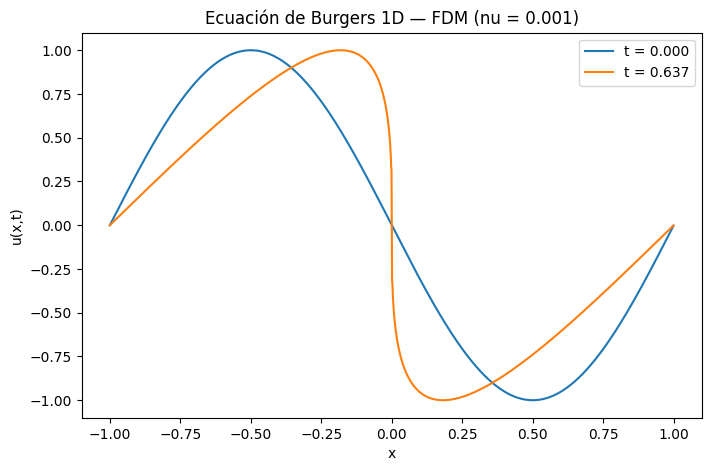

In [ ]:
# Gráfica
nu = 0
nt = 20000
nx = 2000
DT_BURGERS = (X_MAX_BURGERS-X_MIN_BURGERS)/nt

x_normal, U_normal = resolver_burgers_fdm(
    nu, nx, nt,
    x_min=X_MIN_BURGERS, x_max=X_MAX_BURGERS, T=T_BURGERS
)

plt.figure(figsize=(8, 5))

tiempos = [0,  2/np.pi]  
for t in tiempos:
    n = int(round(t / DT_BURGERS))        
    plt.plot(x_normal, U_normal[n], label=f't = {t:.3f}')

plt.xlabel('x')
plt.ylabel('u(x,t)')
plt.legend()
plt.title(f'Ecuación de Burgers 1D — FDM (nu = {NU_BURGERS})')
plt.show()

In [4]:
# Para el cálculo de referencias con mallado fino

if False:
    for nu in [0.05, 0.03, 0.02, 0.015, 0.01, 0.0075, 0.005, 0.001]:
        x_ref, U_ref = resolver_burgers_fdm(
            nu=nu, nx=2000, nt=400000,
            x_min=-1.0, x_max=1.0, T=1.0
        )
        np.savez(f'burgers_referencia_nu_super_fina{nu}.npz', x=x_ref, U=U_ref)
        print(f"Referencia nu={nu} calculada y guardada. Forma de U_ref:", U_ref.shape)

Diferencia relativa entre mallas: nan
Comprobación de estabilidad: 0.004999999999999999


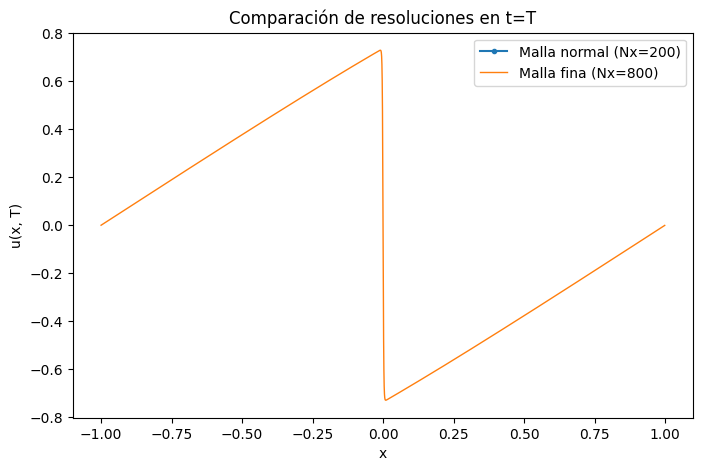

In [5]:
# Interpolación en los puntos x "normales" mediante la curva generada por los puntos x y la matriz U de referencia (malla fina)
datos_burgers_ref = np.load(f'burgers_referencia_nu_super_fina{NU_BURGERS}.npz')
x_ref = datos_burgers_ref['x']
U_ref = datos_burgers_ref['U']


U_ref_interpolado = np.interp(x_normal, x_ref, U_ref[-1])

# Cuanto se  acerca el modelo de malla "mala" al de malla fina
error_resoluciones = np.linalg.norm(U_normal[-1] - U_ref_interpolado) / np.linalg.norm(U_ref_interpolado)
print("Diferencia relativa entre mallas:", error_resoluciones)
print("Comprobación de estabilidad:", MU_BURGERS)

plt.figure(figsize=(8, 5))
plt.plot(x_normal, U_normal[-1], 'o-', label='Malla normal (Nx=200)', markersize=3)
plt.plot(x_ref, U_ref[-1], '-', label='Malla fina (Nx=800)', linewidth=1)
plt.xlabel('x')
plt.ylabel('u(x, T)')
plt.legend()
plt.title('Comparación de resoluciones en t=T')
plt.show()

In [63]:
import zipfile, os
nu_valores = [0.05, 0.03, 0.02, 0.015, 0.01, 0.0075, 0.005, 0.001]
resultados = {}

for nu in nu_valores:
    x_normal, U_normal = resolver_burgers_fdm(
        nu=nu, nx=NX_BURGERS, nt=NT_BURGERS,
        x_min=X_MIN_BURGERS, x_max=X_MAX_BURGERS, T=T_BURGERS
    )

    if os.path.exists('U.npy'):
        try: os.remove('U.npy')
        except PermissionError: pass

    with zipfile.ZipFile(f'burgers_referencia_nu_super_fina{nu}.npz') as zf:
        zf.extract('U.npy', '.')
        with zf.open('x.npy') as f:
            x_ref_nu = np.load(f)

    U_mmap = np.load('U.npy', mmap_mode='r')
    u_ref_final = np.array(U_mmap[-1])
    del U_mmap
    import gc; gc.collect()
    try: os.remove('U.npy')
    except PermissionError: pass

    u_ref_interpolado = np.interp(x_normal, x_ref_nu, u_ref_final)
    error_l2 = np.linalg.norm(U_normal[-1] - u_ref_interpolado) / np.linalg.norm(u_ref_interpolado)
    peclet = 1.0 * (X_MAX_BURGERS - X_MIN_BURGERS) / NX_BURGERS / nu

    resultados[nu] = {
        'x_normal': x_normal,
        'u_normal_final': U_normal[-1],
        'error_l2': error_l2,
        'peclet': peclet,
        'x_ref': x_ref_nu,
        'u_ref_final': u_ref_final
    }

    print(f"nu = {nu:.4f}   Error L2: {error_l2:.6f}   Peclet (malla normal): {peclet:.2f}")

np.savez('burgers_referencias_ultimo_t.npz',
     **{f'x_normal{nu}': resultados[nu]['x_normal'] for nu in nu_valores},
     **{f'U_normal{nu}': resultados[nu]['u_normal_final'] for nu in nu_valores},
     **{f'x_ref_nu{nu}': resultados[nu]['x_ref'] for nu in nu_valores},
     **{f'u_ref_nu{nu}': resultados[nu]['u_ref_final'] for nu in nu_valores},
     **{f'error_l2_nu{nu}': resultados[nu]['error_l2'] for nu in nu_valores},
     **{f'peclet_nu{nu}': resultados[nu]['peclet'] for nu in nu_valores})

print("Referencias ligeras guardadas en burgers_referencias_ultimo_t.npz")

nu = 0.0500   Error L2: 0.000533   Peclet (malla normal): 0.20
nu = 0.0300   Error L2: 0.001241   Peclet (malla normal): 0.33
nu = 0.0200   Error L2: 0.002270   Peclet (malla normal): 0.50


KeyboardInterrupt: 

KeyError: 0.015

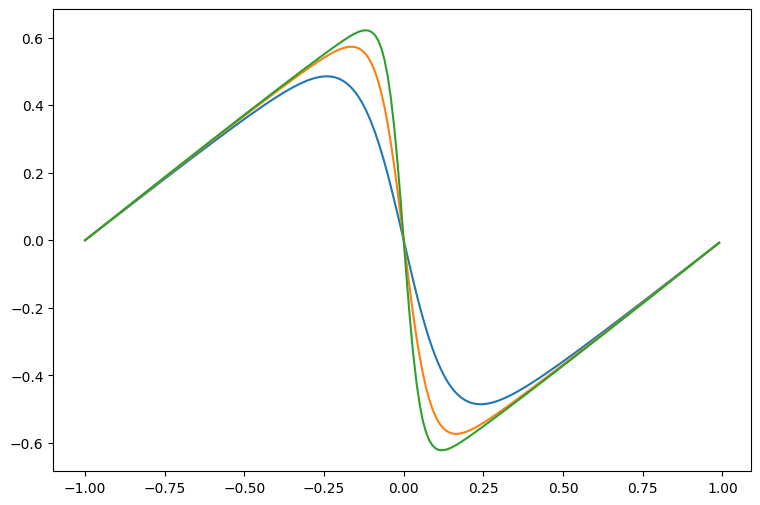

In [81]:
plt.figure(figsize=(9, 6))
for nu in nu_valores:
    x = resultados[nu]['x_normal']
    u = resultados[nu]['u_normal_final']
    plt.plot(x, u, label=f'ν = {nu}')

plt.xlabel('x')
plt.ylabel('u(x, T)')
plt.legend()
plt.title('Ecuación de Burgers 1D — efecto de la viscosidad en t=T')
plt.show()

errores = [resultados[nu]['error_l2'] for nu in nu_valores]

plt.figure(figsize=(7, 5))
plt.plot(nu_valores, errores, 'o-')
plt.xlabel('ν (viscosidad)')
plt.ylabel('Error L2 relativo (malla normal vs. referencia fina)')
plt.title('Error del FDM frente a la referencia, según la viscosidad')
plt.gca().invert_xaxis()
plt.show()